# **Практическое задание №3: Линейная регрессия и функции потерь / Байкалов Сергей Андреевич / 925-М**

***Общее описание задания***

***Тема:*** Исследование влияния функций потерь и гиперпараметров на качество линейной регрессии

***Цель:*** Научиться применять линейную регрессию для решения задач прогнозирования, анализировать влияние выбросов, сравнивать различные функции потерь и подбирать оптимальные гиперпараметры.



### Этап 1: Генерация и подготовка данных
1. Сгенерируйте синтетический датасет согласно вашему варианту
2. Добавьте шум и выбросы в соответствии с параметрами варианта
3. Разделите данные на обучающую и тестовую выборки (70/30)
4. Выполните масштабирование признаков

In [1]:
# библиотека numpy
import numpy as np

# библиотека pandas
import pandas as pd

# библиотека для графиков
import matplotlib.pyplot as plt

# библиотека seaborn
import seaborn as sns

# разделение данных на выборки
from sklearn.model_selection import train_test_split

# нормализация данных
from sklearn.preprocessing import StandardScaler


# функция генерации датасета
def generate_dataset(
    n_samples=500,
    n_features=2,
    noise_std=0.5,
    outlier_fraction=0.05,
    outlier_multiplier=3,
    random_seed=None
):

    # случайное число для повторяемости результатов
    if random_seed is not None:
        np.random.seed(random_seed)

    # признаки датасета
    X = np.random.randn(
        n_samples,
        n_features
    )

    # истинные коэффициенты модели
    true_coef = np.random.uniform(
        1,
        5,
        n_features
    )

    # истинное смещение модели
    true_intercept = np.random.uniform(
        0,
        10
    )

    # целевая переменная
    y = (
        X @ true_coef
        + true_intercept
        + np.random.randn(n_samples) * noise_std
    )

    # количество выбросов
    n_outliers = int(
        n_samples * outlier_fraction
    )

    # индексы выбросов
    outlier_idx = np.random.choice(
        n_samples,
        n_outliers,
        replace=False
    )

    # добавление выбросов
    y[outlier_idx] += (
        np.random.choice(
            [-1, 1],
            n_outliers
        )
        *
        np.random.uniform(
            3,
            10,
            n_outliers
        )
        *
        outlier_multiplier
    )

    # результат работы функции
    return (
        X,
        y,
        true_coef,
        true_intercept
    )


# названия признаков
features = [
    "area",
    "rooms"
]

# название целевой переменной
target = "price"

# генерация датасета
X, y, true_w, true_b = generate_dataset(
    n_samples=500,
    n_features=2,
    noise_std=0.5,
    outlier_fraction=0.05,
    outlier_multiplier=3,
    random_seed=1
)

# таблица признаков
df = pd.DataFrame(
    X,
    columns=features
)

# столбец целевой переменной
df[target] = y

# первые строки таблицы
print("Первые строки датасета:")
print(df.head())

# истинные параметры модели
print("Истинные коэффициенты модели:")

# коэффициенты
print("weights:", true_w)

# смещение
print("intercept:", true_b)

Первые строки датасета:
       area     rooms     price
0  1.624345 -0.611756  4.729969
1 -0.528172 -1.072969 -1.543462
2  0.865408 -2.301539 -1.561585
3  1.744812 -0.761207  4.236869
4  0.319039 -0.249370  2.513072
Истинные коэффициенты модели:
weights: [2.54795694 2.97152349]
intercept: 2.544381023144221


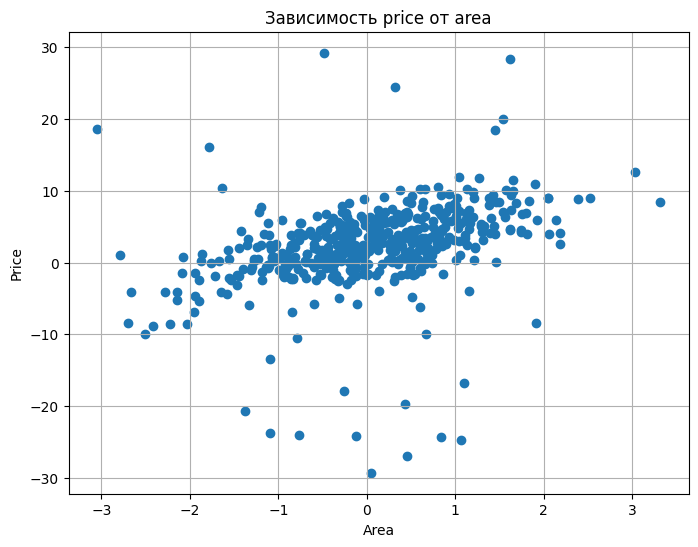

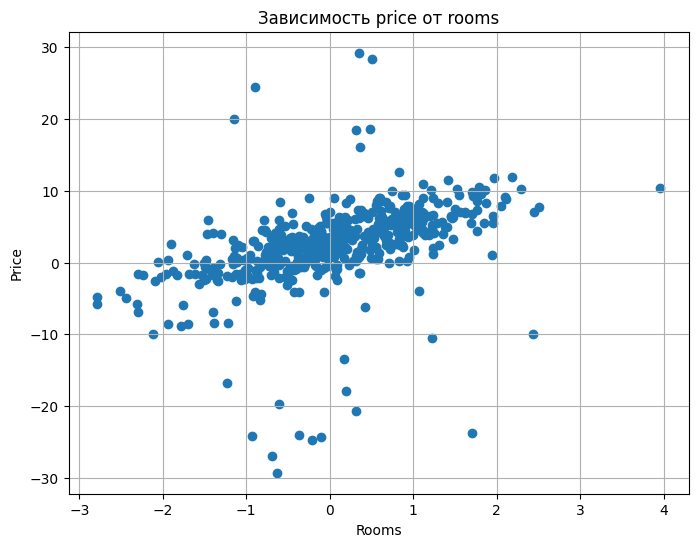

In [2]:
# окно графика
plt.figure(figsize=(8, 6))

# точки для area и price
plt.scatter(
    df["area"],
    df["price"]
)

# подпись оси x
plt.xlabel("Area")

# подпись оси y
plt.ylabel("Price")

# заголовок графика
plt.title("Зависимость price от area")

# сетка
plt.grid()

# отображение графика
plt.show()

# окно графика
plt.figure(figsize=(8, 6))

# точки для rooms и price
plt.scatter(
    df["rooms"],
    df["price"]
)

# подпись оси x
plt.xlabel("Rooms")

# подпись оси y
plt.ylabel("Price")

# заголовок графика
plt.title("Зависимость price от rooms")

# сетка
plt.grid()

# отображение графика
plt.show()

In [3]:
# признаки
X = df[features]

# целевая переменная
y = df[target]

# разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# размер обучающей выборки
print(
    "Train shape:",
    X_train.shape
)

# размер тестовой выборки
print(
    "Test shape:",
    X_test.shape
)

Train shape: (350, 2)
Test shape: (150, 2)


In [4]:
# объект для нормализации данных
scaler = StandardScaler()

# нормализация обучающей выборки
X_train_scaled = scaler.fit_transform(
    X_train
)

# нормализация тестовой выборки
X_test_scaled = scaler.transform(
    X_test
)

# таблица обучающей выборки после нормализации
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=features
)

# таблица тестовой выборки после нормализации
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=features
)

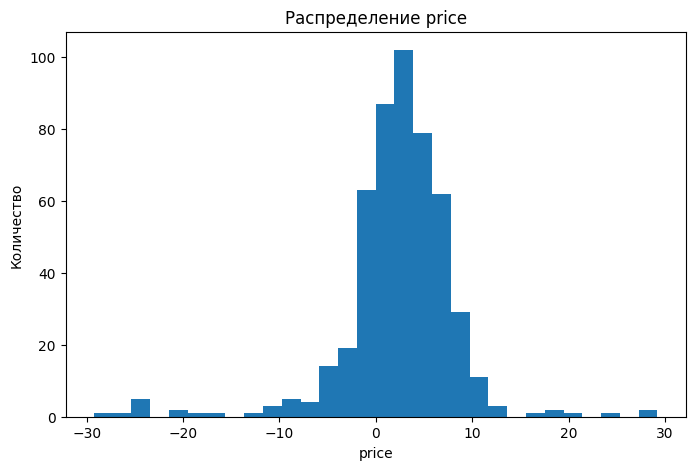

In [5]:
# окно графика
plt.figure(figsize=(8, 5))

# распределение цены
plt.hist(
    df["price"],
    bins=30
)

# заголовок графика
plt.title(
    "Распределение price"
)

# подпись оси x
plt.xlabel(
    "price"
)

# подпись оси y
plt.ylabel(
    "Количество"
)

# отображение графика
plt.show()

### Этап 2: Разведочный анализ данных (EDA)
1. Постройте матрицу корреляций признаков (heatmap)
2. Создайте pairplot для визуализации линейных зависимостей
3. Проанализируйте распределение целевой переменной
4. Выявите и визуализируйте выбросы

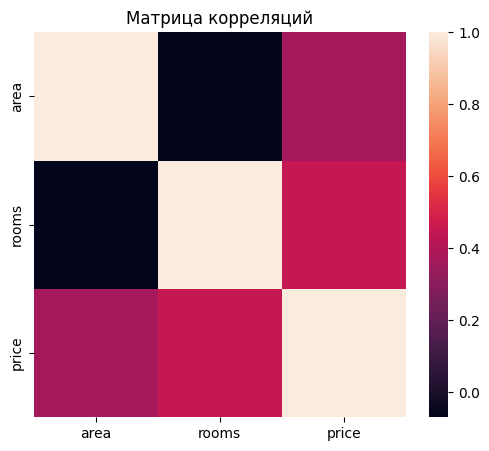

In [6]:
# окно графика
plt.figure(figsize=(6, 5))

# корреляционная матрица
corr = df.corr()

# тепловая карта корреляций
sns.heatmap(
    corr
)

# заголовок графика
plt.title(
    "Матрица корреляций"
)

# отображение графика
plt.show()

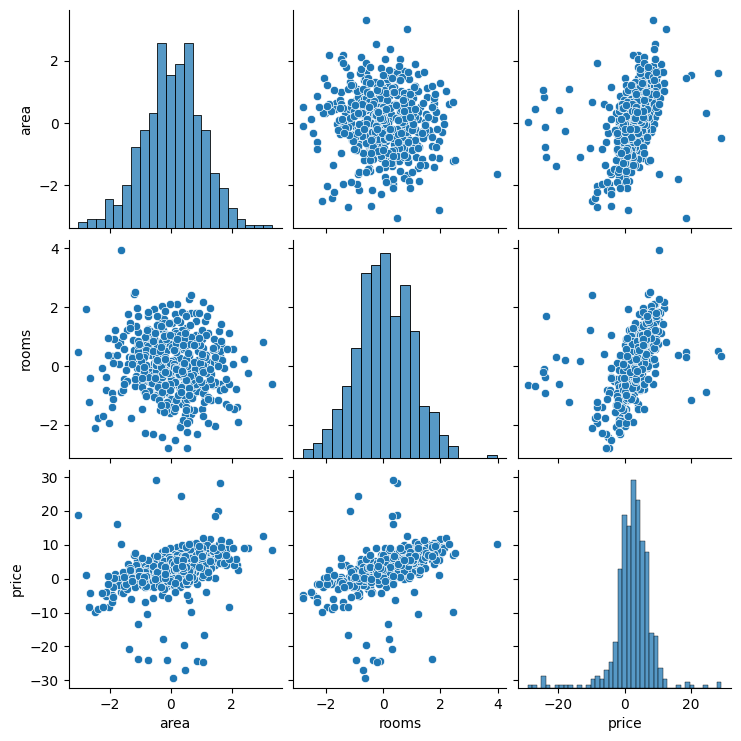

In [7]:
# график парных зависимостей
sns.pairplot(df)

# отображение графика
plt.show()

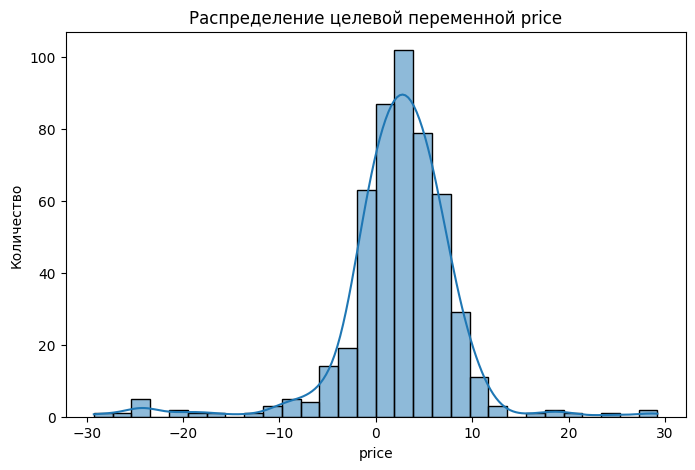

In [8]:
# окно графика
plt.figure(figsize=(8, 5))

# распределение цены
sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

# заголовок графика
plt.title(
    "Распределение целевой переменной price"
)

# подпись оси x
plt.xlabel(
    "price"
)

# подпись оси y
plt.ylabel(
    "Количество"
)

# отображение графика
plt.show()

Распределение целевой переменной близко к нормальному, однако наблюдаются отдельные экстремальные значения. Эти значения вызваны искусственно добавленными выбросами и приводят к увеличению дисперсии распределения.

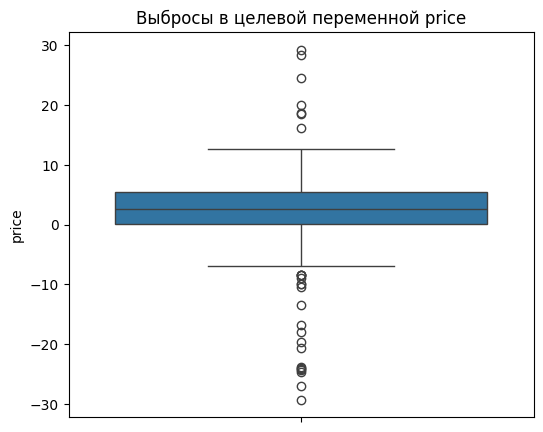

In [10]:
# окно графика
plt.figure(figsize=(6, 5))

# boxplot для цены
sns.boxplot(
    y=df["price"]
)

# заголовок графика
plt.title(
    "Выбросы в целевой переменной price"
)

# отображение графика
plt.show()


### Этап 3: Обучение моделей
1. Обучите три модели:
   - `LinearRegression` (минимизация MSE)
   - `HuberRegressor` с параметром `epsilon` из варианта
   - `SGDRegressor` с параметром `loss` из варианта
2. Зафиксируйте коэффициенты модели и свободный член

In [15]:
# линейная регрессия
from sklearn.linear_model import LinearRegression

# робастная регрессия
from sklearn.linear_model import HuberRegressor

# стохастический градиентный спуск
from sklearn.linear_model import SGDRegressor


# модель линейной регрессии
model_lr = LinearRegression()

# обучение модели
model_lr.fit(
    X_train_scaled,
    y_train
)

# предсказание на тесте
y_pred_lr = model_lr.predict(
    X_test_scaled
)

# вывод названия модели
print("LinearRegression")

# коэффициенты модели
print("coefficients:", model_lr.coef_)

# свободный член модели
print("intercept:", model_lr.intercept_)

LinearRegression
coefficients: [2.31133106 3.01713413]
intercept: 2.609925539255204


In [16]:
# параметр устойчивости к выбросам
epsilon = 1.35

# модель робастной регрессии
model_huber = HuberRegressor(
    epsilon=epsilon
)

# обучение модели
model_huber.fit(
    X_train_scaled,
    y_train
)

# предсказание на тестовой выборке
y_pred_huber = model_huber.predict(
    X_test_scaled
)

# вывод названия модели
print("HuberRegressor")

# коэффициенты модели
print("coefficients:", model_huber.coef_)

# свободный член модели
print("intercept:", model_huber.intercept_)

HuberRegressor
coefficients: [2.56984754 3.01054579]
intercept: 2.8475380528050596


In [17]:
# функция потерь
loss = "huber"

# модель стохастического градиентного спуска
model_sgd = SGDRegressor(
    loss=loss,
    max_iter=1000,
    random_state=42
)

# обучение модели
model_sgd.fit(
    X_train_scaled,
    y_train
)

# предсказание на тестовой выборке
y_pred_sgd = model_sgd.predict(
    X_test_scaled
)

# вывод названия модели
print("SGDRegressor")

# коэффициенты модели
print("coefficients:", model_sgd.coef_)

# свободный член модели
print("intercept:", model_sgd.intercept_)

SGDRegressor
coefficients: [1.85458037 2.27354976]
intercept: [2.2873248]


In [18]:
# таблица сравнения моделей
coef_table = pd.DataFrame({

    # названия моделей
    "Model": [
        "LinearRegression",
        "HuberRegressor",
        "SGDRegressor"
    ],

    # коэффициент при area
    "coef_area": [
        model_lr.coef_[0],
        model_huber.coef_[0],
        model_sgd.coef_[0]
    ],

    # коэффициент при rooms
    "coef_rooms": [
        model_lr.coef_[1],
        model_huber.coef_[1],
        model_sgd.coef_[1]
    ],

    # свободный член модели
    "intercept": [
        model_lr.intercept_,
        model_huber.intercept_,
        model_sgd.intercept_
    ]
})

# вывод таблицы
coef_table

,Model,coef_area,coef_rooms,intercept
0,LinearRegression,2.311331,3.017134,2.609926
1,HuberRegressor,2.569848,3.010546,2.847538
2,SGDRegressor,1.854580,2.273550,[2.2873248008052522]


### Этап 4: Оценка качества
1. Рассчитайте метрики на тестовой выборке:
   - MSE, RMSE, MAE, R²
2. Постройте графики:
   - Фактические vs предсказанные значения
   - Остатки модели (residual plot)
   - Сравнение предсказаний трёх моделей


In [19]:
# метрики качества моделей
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# библиотека numpy
import numpy as np

# таблица для хранения результатов
metrics = pd.DataFrame(
    columns=["Model", "MSE", "RMSE", "MAE", "R2"]
)

# функция расчёта метрик
def calculate_metrics(name, y_true, y_pred):

    # среднеквадратичная ошибка
    mse = mean_squared_error(y_true, y_pred)

    # корень из mse
    rmse = np.sqrt(mse)

    # средняя абсолютная ошибка
    mae = mean_absolute_error(y_true, y_pred)

    # коэффициент детерминации
    r2 = r2_score(y_true, y_pred)

    # строка с результатами
    return pd.DataFrame(
        [[name, mse, rmse, mae, r2]],
        columns=["Model", "MSE", "RMSE", "MAE", "R2"]
    )

# объединение результатов всех моделей
metrics = pd.concat([
    calculate_metrics(
        "LinearRegression",
        y_test,
        y_pred_lr
    ),

    calculate_metrics(
        "HuberRegressor",
        y_test,
        y_pred_huber
    ),

    calculate_metrics(
        "SGDRegressor",
        y_test,
        y_pred_sgd
    )
])

# итоговая таблица
metrics

,Model,MSE,RMSE,MAE,R2
0,LinearRegression,21.191956,4.603472,1.283902,0.316642
0,HuberRegressor,21.389636,4.624893,1.201661,0.310268
0,SGDRegressor,21.322487,4.617628,1.658015,0.312433


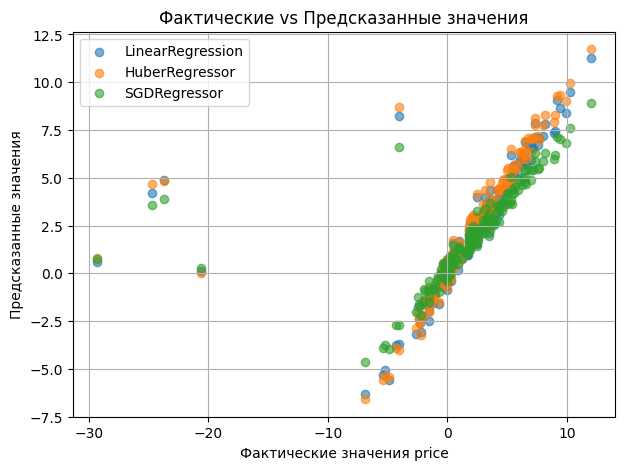

In [20]:
# окно графика
plt.figure(figsize=(7, 5))

# фактические vs предсказанные (LinearRegression)
plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.6,
    label="LinearRegression"
)

# фактические vs предсказанные (Huber)
plt.scatter(
    y_test,
    y_pred_huber,
    alpha=0.6,
    label="HuberRegressor"
)

# фактические vs предсказанные (SGD)
plt.scatter(
    y_test,
    y_pred_sgd,
    alpha=0.6,
    label="SGDRegressor"
)

# подпись оси x
plt.xlabel("Фактические значения price")

# подпись оси y
plt.ylabel("Предсказанные значения")

# заголовок графика
plt.title("Фактические vs Предсказанные значения")

# легенда
plt.legend()

# сетка
plt.grid(True)

# отображение графика
plt.show()

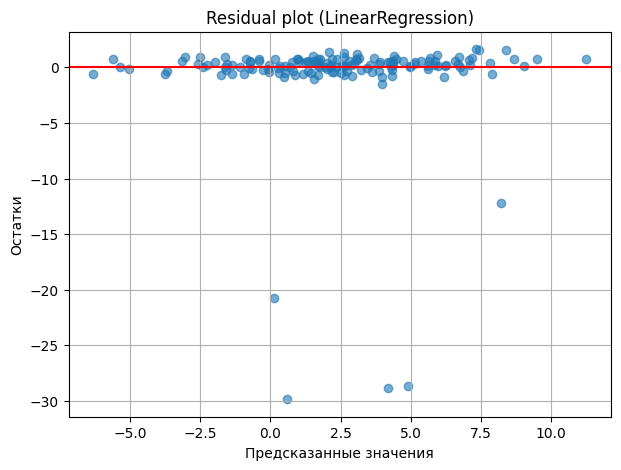

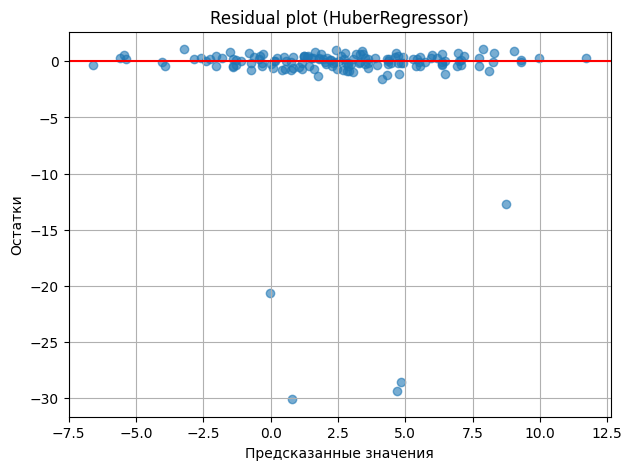

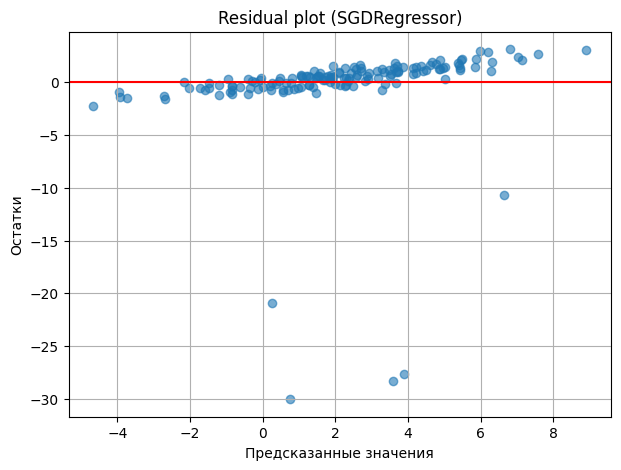

In [21]:
# ошибки (остатки) для LinearRegression
residuals_lr = y_test - y_pred_lr

# ошибки (остатки) для HuberRegressor
residuals_huber = y_test - y_pred_huber

# ошибки (остатки) для SGDRegressor
residuals_sgd = y_test - y_pred_sgd


# график остатков (LinearRegression)
plt.figure(figsize=(7, 5))

# предсказания vs ошибки
plt.scatter(
    y_pred_lr,
    residuals_lr,
    alpha=0.6
)

# линия нулевой ошибки
plt.axhline(0, color="red")

# подпись оси x
plt.xlabel("Предсказанные значения")

# подпись оси y
plt.ylabel("Остатки")

# заголовок
plt.title("Residual plot (LinearRegression)")

# сетка
plt.grid(True)

# отображение
plt.show()


# график остатков (HuberRegressor)
plt.figure(figsize=(7, 5))

# предсказания vs ошибки
plt.scatter(
    y_pred_huber,
    residuals_huber,
    alpha=0.6
)

# линия нуля
plt.axhline(0, color="red")

# подпись оси x
plt.xlabel("Предсказанные значения")

# подпись оси y
plt.ylabel("Остатки")

# заголовок
plt.title("Residual plot (HuberRegressor)")

# сетка
plt.grid(True)

# отображение
plt.show()


# график остатков (SGDRegressor)
plt.figure(figsize=(7, 5))

# предсказания vs ошибки
plt.scatter(
    y_pred_sgd,
    residuals_sgd,
    alpha=0.6
)

# линия нулевой ошибки
plt.axhline(0, color="red")

# подпись оси x
plt.xlabel("Предсказанные значения")

# подпись оси y
plt.ylabel("Остатки")

# заголовок
plt.title("Residual plot (SGDRegressor)")

# сетка
plt.grid(True)

# отображение
plt.show()

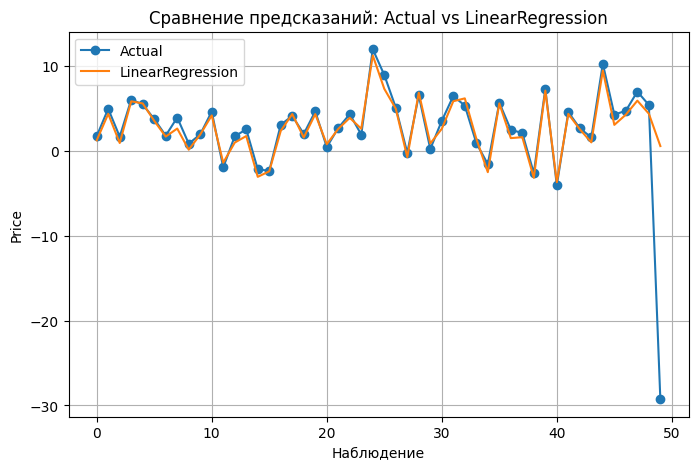

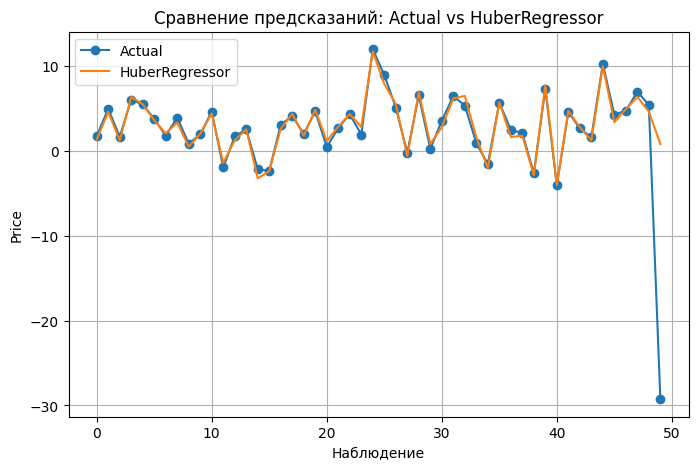

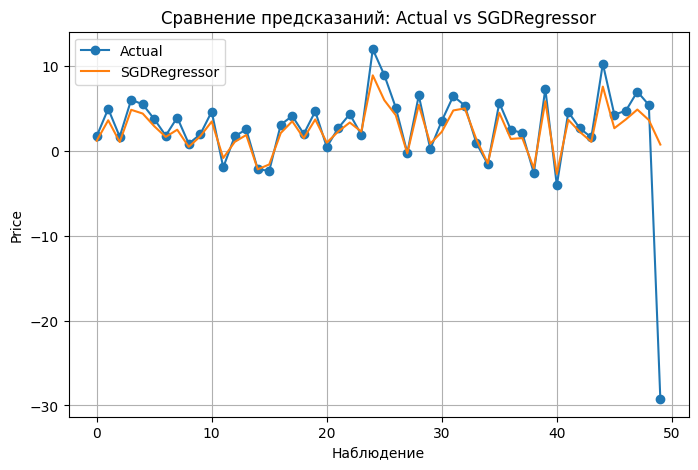

In [ ]:
# библиотека для графиков
import matplotlib.pyplot as plt


# график сравнения (LinearRegression)
plt.figure(figsize=(8, 5))

# реальные значения (первые 50)
plt.plot(
    y_test.values[:50],
    label="Actual",
    marker="o"
)

# предсказания модели
plt.plot(
    y_pred_lr[:50],
    label="LinearRegression"
)

# заголовок
plt.title("Сравнение предсказаний: Actual vs LinearRegression")

# подпись оси x
plt.xlabel("Наблюдение")

# подпись оси y
plt.ylabel("Price")

# легенда
plt.legend()

# сетка
plt.grid(True)

# отображение
plt.show()


# график сравнения (HuberRegressor)
plt.figure(figsize=(8, 5))

# реальные значения (первые 50)
plt.plot(
    y_test.values[:50],
    label="Actual",
    marker="o"
)

# предсказания модели
plt.plot(
    y_pred_huber[:50],
    label="HuberRegressor"
)

# заголовок
plt.title("Сравнение предсказаний: Actual vs HuberRegressor")

# подпись оси x
plt.xlabel("Наблюдение")

# подпись оси y
plt.ylabel("Price")

# легенда
plt.legend()

# сетка
plt.grid(True)

# отображение
plt.show()


# график сравнения (SGDRegressor)
plt.figure(figsize=(8, 5))

# реальные значения (первые 50)
plt.plot(
    y_test.values[:50],
    label="Actual",
    marker="o"
)

# предсказания модели
plt.plot(
    y_pred_sgd[:50],
    label="SGDRegressor"
)

# заголовок
plt.title("Сравнение предсказаний: Actual vs SGDRegressor")

# подпись оси x
plt.xlabel("Наблюдение")

# подпись оси y
plt.ylabel("Price")

# легенда
plt.legend()

# сетка
plt.grid(True)

# отображение
plt.show()


### Этап 5: Анализ устойчивости
1. Исследуйте влияние выбросов на каждую модель
2. Проанализируйте, как параметр `epsilon` влияет на робастность HuberRegressor
3. Сделайте выводы о применимости каждой функции потерь

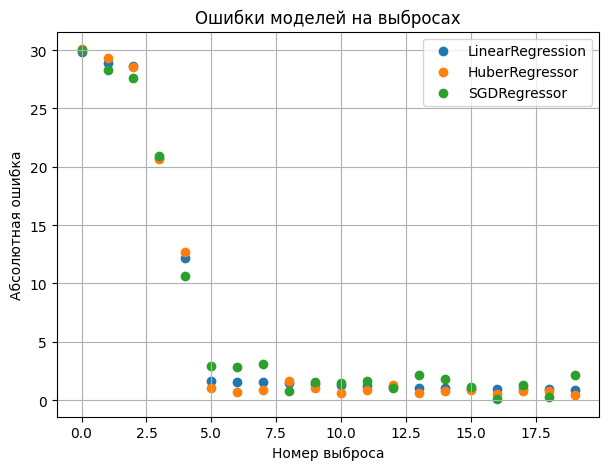

In [ ]:
# абсолютные ошибки LinearRegression
errors_lr = np.abs(y_test - y_pred_lr)

# абсолютные ошибки HuberRegressor
errors_huber = np.abs(y_test - y_pred_huber)

# абсолютные ошибки SGDRegressor
errors_sgd = np.abs(y_test - y_pred_sgd)


# 20 самых больших ошибок LinearRegression
outlier_labels = errors_lr.nlargest(20).index


# окно графика
plt.figure(figsize=(7, 5))

# ошибки LinearRegression на выбросах
plt.scatter(
    range(len(outlier_labels)),
    errors_lr[outlier_labels],
    label="LinearRegression"
)

# ошибки HuberRegressor на тех же точках
plt.scatter(
    range(len(outlier_labels)),
    errors_huber[outlier_labels],
    label="HuberRegressor"
)

# ошибки SGDRegressor на тех же точках
plt.scatter(
    range(len(outlier_labels)),
    errors_sgd[outlier_labels],
    label="SGDRegressor"
)

# заголовок графика
plt.title("Ошибки моделей на выбросах")

# подпись оси x
plt.xlabel("Номер выброса")

# подпись оси y
plt.ylabel("Абсолютная ошибка")

# легенда
plt.legend()

# сетка
plt.grid(True)

# отображение
plt.show()

In [ ]:
# разные значения epsilon
eps_values = [1.0, 1.35, 1.8, 2.5]

# список для результатов
results = []

# перебор epsilon
for eps in eps_values:

    # модель HuberRegressor
    model = HuberRegressor(
        epsilon=eps
    )

    # обучение модели
    model.fit(
        X_train_scaled,
        y_train
    )

    # предсказание
    pred = model.predict(
        X_test_scaled
    )

    # среднеквадратичная ошибка
    mse = mean_squared_error(
        y_test,
        pred
    )

    # средняя абсолютная ошибка
    mae = mean_absolute_error(
        y_test,
        pred
    )

    # коэффициент детерминации
    r2 = r2_score(
        y_test,
        pred
    )

    # сохранение результата
    results.append([
        eps,
        mse,
        mae,
        r2
    ])


# таблица результатов
results_df = pd.DataFrame(
    results,
    columns=["epsilon", "MSE", "MAE", "R2"]
)

# вывод таблицы
results_df

,epsilon,MSE,MAE,R2
0,1.00,21.425511,1.202996,0.309111
1,1.35,21.389636,1.201661,0.310268
2,1.80,21.391518,1.200569,0.310207
3,2.50,21.390169,1.200840,0.310251


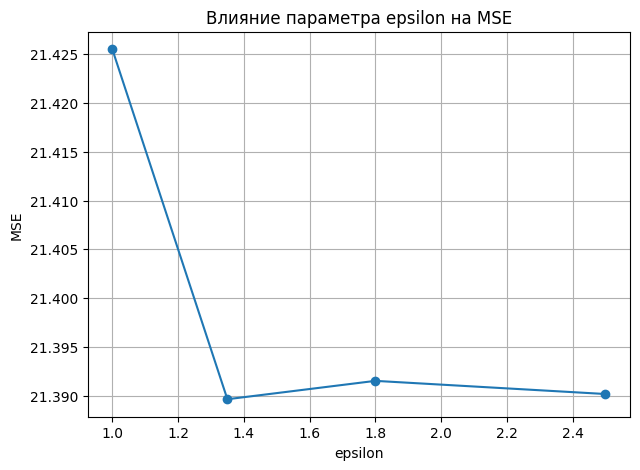

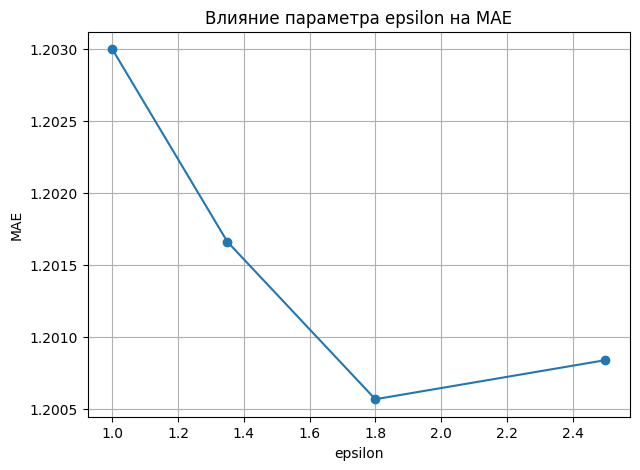

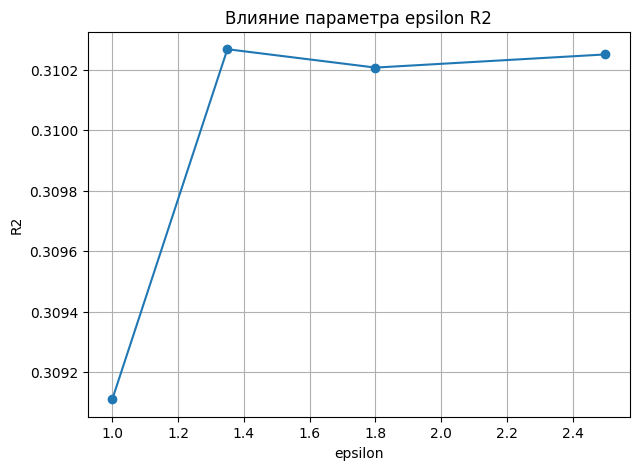

In [ ]:
# график MSE
plt.figure(figsize=(7, 5))

# зависимость MSE от epsilon
plt.plot(
    results_df["epsilon"],
    results_df["MSE"],
    marker="o"
)

# заголовок
plt.title("Влияние параметра epsilon на MSE")

# подпись оси x
plt.xlabel("epsilon")

# подпись оси y
plt.ylabel("MSE")

# сетка
plt.grid(True)

# отображение
plt.show()


# график MAE
plt.figure(figsize=(7, 5))

# зависимость MAE от epsilon
plt.plot(
    results_df["epsilon"],
    results_df["MAE"],
    marker="o"
)

# заголовок
plt.title("Влияние параметра epsilon на MAE")

# подпись оси x
plt.xlabel("epsilon")

# подпись оси y
plt.ylabel("MAE")

# сетка
plt.grid(True)

# отображение
plt.show()


# график R2
plt.figure(figsize=(7, 5))

# зависимость R2 от epsilon
plt.plot(
    results_df["epsilon"],
    results_df["R2"],
    marker="o"
)

# заголовок
plt.title("Влияние параметра epsilon на R2")

# подпись оси x
plt.xlabel("epsilon")

# подпись оси y
plt.ylabel("R2")

# сетка
plt.grid(True)

# отображение
plt.show()

**MSE**

Квадратичная функция потерь сильно увеличивает влияние больших ошибок. Это приводит к высокой чувствительности модели к выбросам, что может ухудшать точность предсказаний на данных с аномальными наблюдениями.

**Huber Loss**

Комбинирует квадратичную и линейную функции потерь. Для небольших ошибок используется квадратичная зависимость, а для больших — линейная. Благодаря этому модель сохраняет точность на нормальных данных и одновременно уменьшает влияние выбросов.

**Huber Loss в SGDRegressor**

Стохастический градиентный спуск позволяет эффективно обучать модель на больших наборах данных. Использование робастной функции потерь делает алгоритм устойчивым к шуму и аномальным значениям.